In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [2]:
data = pd.read_csv("smartcart_customers.csv")

In [4]:
data.head()
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1.Handle Missing Values

In [7]:
data["Income"] = data["Income"].fillna(data["Income"].median())

In [9]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature engineering

In [12]:
#Age
data["Age"] = 2026-data["Year_Birth"]

In [14]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [17]:
#Customer Joining Date
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)

reference_date = data["Dt_Customer"].max()   #it refersto today's time

data["Customer_Tenure_Days"]= (reference_date - data["Dt_Customer"]).dt.days

In [19]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [25]:
#Spending
data["Total_Spending"] = data["MntWines"]+data["MntFruits"]+data["MntMeatProducts"]+data["MntFishProducts"]+data["MntSweetProducts"]+data["MntGoldProds"]

In [26]:
data["Total_Children"] = data["Kidhome"]+data["Teenhome"]

In [28]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [33]:
#Education
data["Education"].value_counts()

data["Education"] = data["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
})

In [34]:
data["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [41]:
#Marital Status

data["Living_With"] = data["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Absurd":"Alone","YOLO":"Alone",
    "Divorced":"Alone","Widow":"Alone"
})

In [42]:
#Marital Status

data["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# Drop Columns


In [44]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

data_cleaned = data.drop(columns=cols_to_drop)

In [45]:
data_cleaned.shape

(2240, 15)

# Outlier

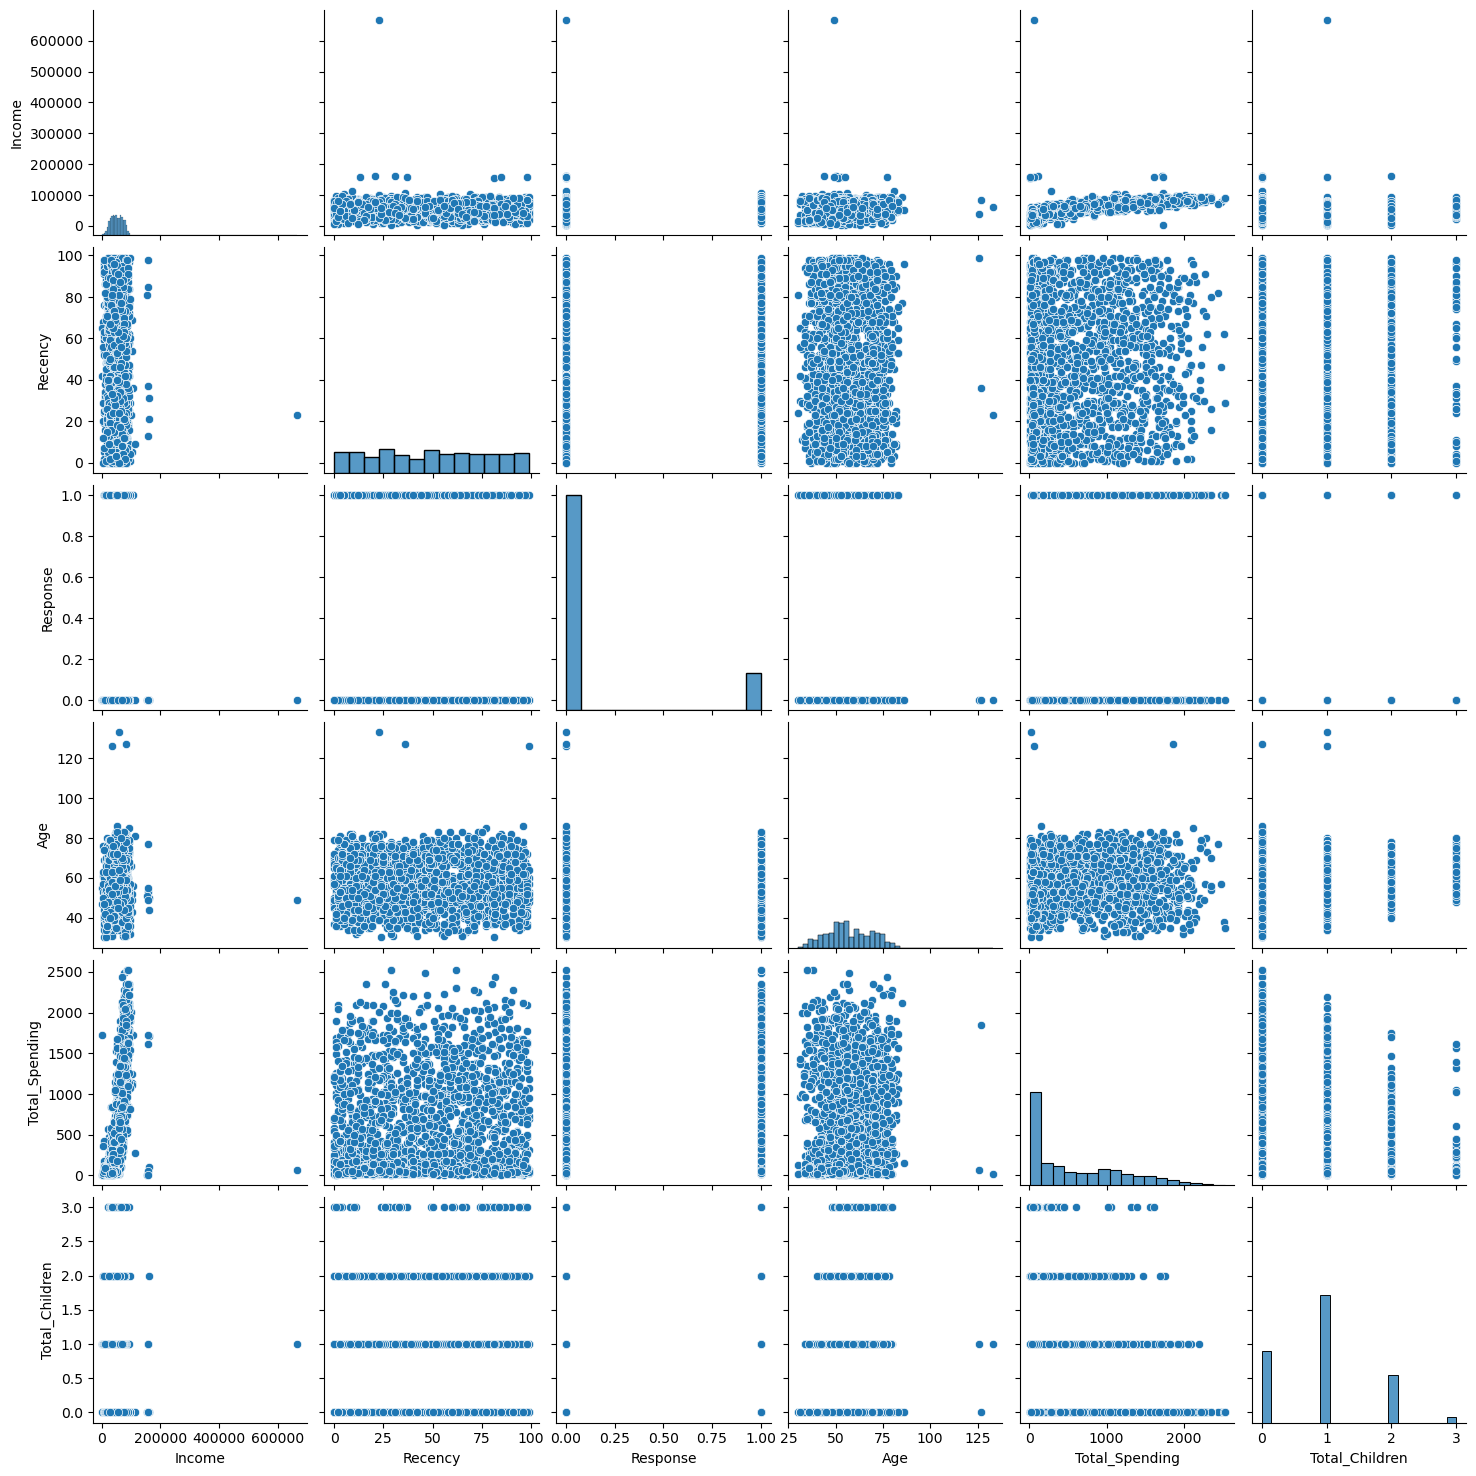

In [46]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

#relative plots of some feature- pair plots
sns.pairplot(data_cleaned[cols])

In [47]:
#Remove Outliers

print("data size with outliers:", len(data_cleaned))

data_cleaned = data_cleaned[ (data_cleaned["Age"] < 90) ]
data_cleaned = data_cleaned[ (data_cleaned["Income"] < 600_000) ]

print("data size without outliers:", len(data_cleaned))


data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [49]:
corr = data_cleaned.corr(numeric_only=True)

<Axes: >

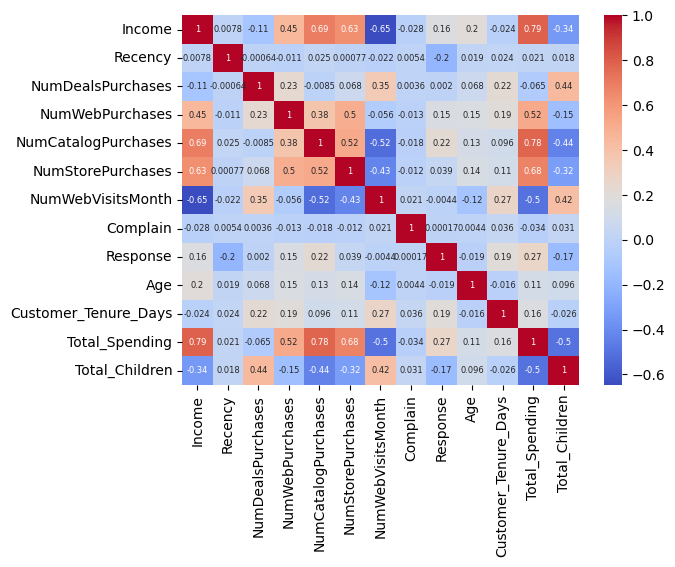

In [52]:
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# Encoding

In [53]:
from sklearn.preprocessing import OneHotEncoder

In [57]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(data_cleaned[cat_cols])

In [58]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=data_cleaned.index)

In [60]:
df_encoded = pd.concat([data_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [61]:
df_encoded.shape

(2236, 18)

In [62]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [64]:
from sklearn.preprocessing import StandardScaler

In [65]:
x = df_encoded

In [67]:
scaled = StandardScaler()
x_scaled = scaled.fit_transform(x)

# Visualize

In [68]:
x_scaled.shape

(2236, 18)

In [69]:
#2D
from sklearn.decomposition import PCA

In [73]:
pca = PCA(n_components=3)

x_pca = pca.fit_transform(x_scaled)

In [75]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

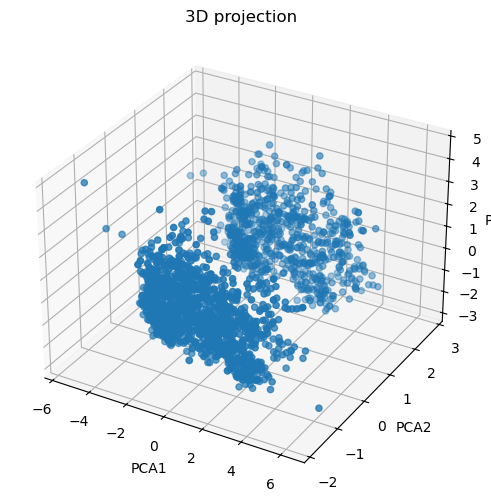

In [78]:
#plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")


In [72]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

# Elbow Method

In [81]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [82]:
knee = KneeLocator(range(1,11),wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [83]:
print("best k=",optimal_k)

best k= 4


Text(0, 0.5, 'WCSS')

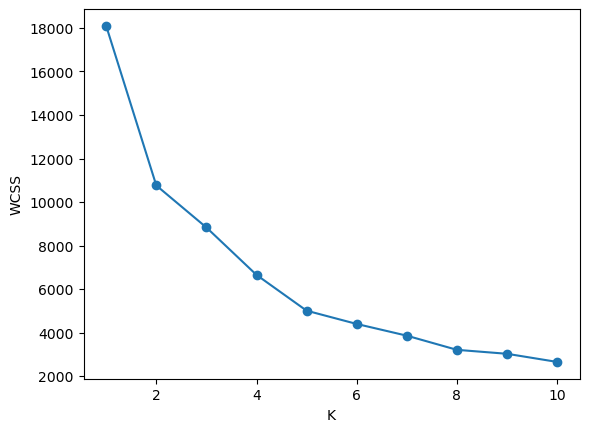

In [85]:
#plot

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")

# 2.Silhouette Score

Text(0, 0.5, 'Silhouette score')

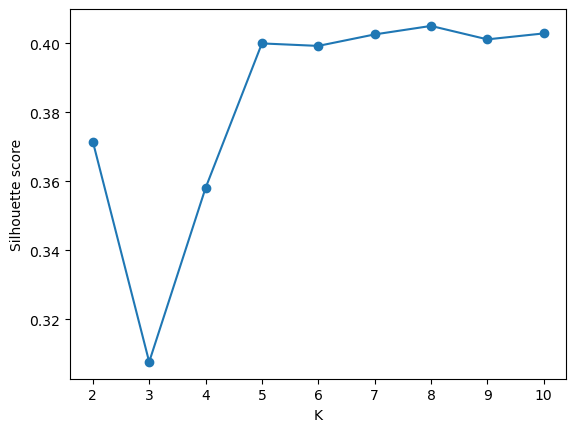

In [88]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11), scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'Silhouette score')

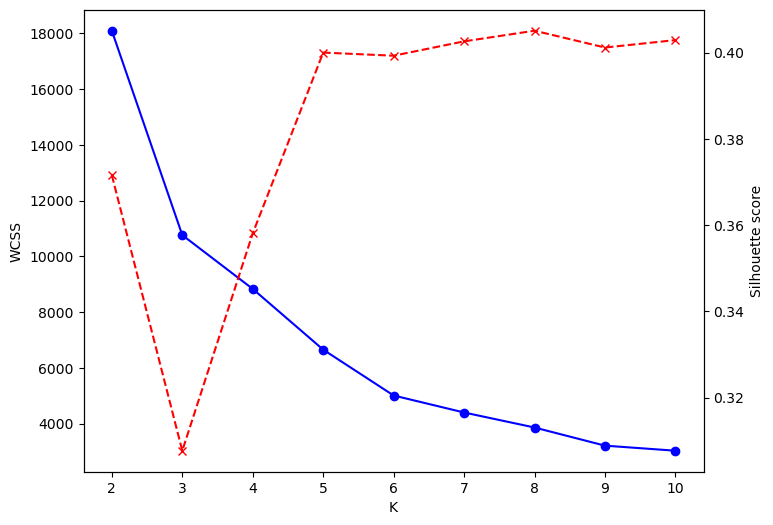

In [93]:
#Combined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("Silhouette score")

# Clustering

In [94]:
#Kmeans

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans= kmeans.fit_predict(x_pca)

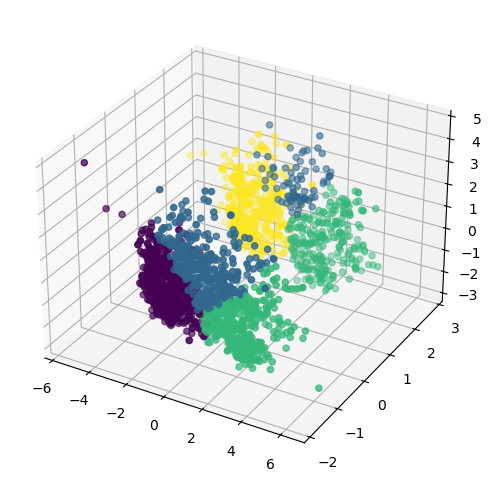

In [96]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c=labels_kmeans)

In [97]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

In [99]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(x_pca)

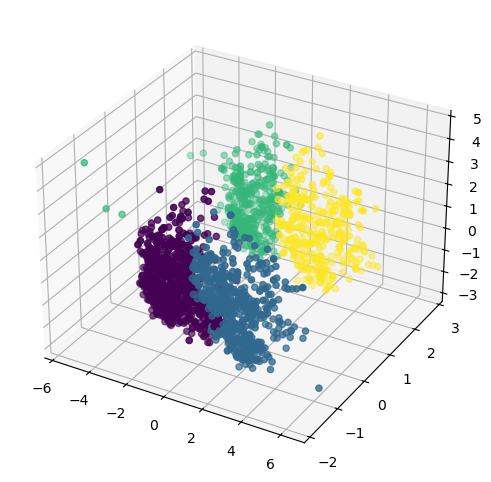

In [100]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0], x_pca[:,1], x_pca[:,2], c=labels_agg)

# Characterization of cluster

In [118]:
#Agglomerative clustering is best
x["cluster"] = labels_agg

In [119]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

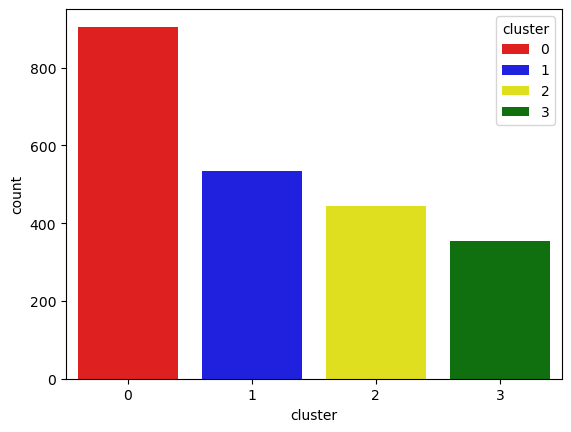

In [120]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=x["cluster"], palette=pal,hue=x["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

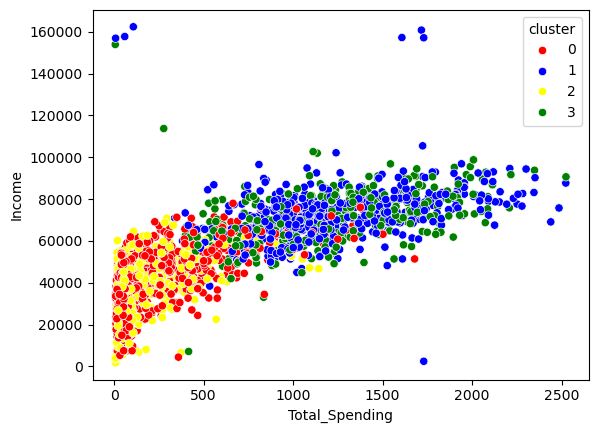

In [121]:
# Income & Spending patterns

sns.scatterplot(x=x["Total_Spending"], y=x["Income"], hue=data_cleaned["cluster"],palette=pal)

In [123]:
#Cluster Summary 
cluster_summary = x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         